<a href="https://colab.research.google.com/github/ChiaraTagiullo/olympic-power-structure/blob/main/Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olympic Power Structure — Exploratory Analysis

## Goal

Explore how Olympic success is distributed across countries and over time.

Main question:
Is Olympic success evenly distributed, or concentrated among a few dominant countries?

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import os

pd.set_option("display.max_columns", None)

## 1. Upload the cleaned dataset

This notebook starts from the cleaned country-year dataset produced in the data preparation notebook.

In [11]:
uploaded = files.upload()

Saving olympics_country_year.csv to olympics_country_year (1).csv


In [12]:
print(os.listdir())

['.config', 'olympics_country_year (1).csv', 'olympics_country_year.csv', 'sample_data']


In [13]:
df = pd.read_csv("olympics_country_year.csv", sep=";")
display(df.head())
print(df.columns.tolist())

,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share,Top10_Flag
0,GRE,1896,10,17,17,44,1,120,"3,66667E+16",VERO
1,USA,1896,11,6,2,19,2,120,"1,58333E+16",VERO
2,GER,1896,7,5,2,14,3,120,"1,16667E+16",VERO
3,FRA,1896,5,4,2,11,4,120,"9,16667E+15",VERO
4,GBR,1896,3,3,3,9,5,120,75,VERO


['NOC', 'Year', 'Gold', 'Silver', 'Bronze', 'Total_Medals', 'Rank', 'Year_Total_Medals', 'Medal_Share', 'Top10_Flag']


## 2. Medal concentration across countries

First, I aggregate total medals per country across all Olympic years.
This helps identify whether Olympic success is broadly distributed or concentrated among a limited number of countries.

In [14]:
country_total = (
    df.groupby("NOC")["Total_Medals"]
    .sum()
    .reset_index()
    .sort_values("Total_Medals", ascending=False)
)

country_total.head(10)

,NOC,Total_Medals
141,USA,2823
139,URS,1197
49,GER,1004
46,GBR,919
43,FRA,879
67,ITA,722
123,SWE,657
22,CHN,595
112,RUS,584
47,GDR,519


## 3. Share of medals captured by the top 10 countries

In [15]:
top10_total = country_total.head(10)["Total_Medals"].sum()
world_total = country_total["Total_Medals"].sum()

top10_share = top10_total / world_total

top10_share

np.float64(0.5236180904522613)

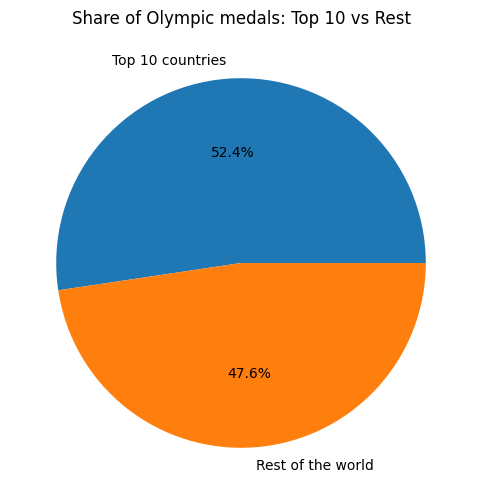

In [16]:
labels = ["Top 10 countries", "Rest of the world"]
values = [top10_total, world_total - top10_total]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Share of Olympic medals: Top 10 vs Rest")
plt.show()

## Interpretation

The top 10 countries account for approximately 52% of all Olympic medals.

This is a striking result:
just a small group of countries captures more than half of the total medal pool.

This clearly indicates that Olympic success is highly concentrated and not evenly distributed across nations.

Rather than reflecting a level playing field, this pattern suggests the presence of structural inequalities between countries.

## 4. Cumulative distribution of medals

To better understand inequality, I analyze how medals accumulate across countries ranked from highest to lowest total medal count.

In [17]:
country_total_sorted = country_total.sort_values("Total_Medals", ascending=False).copy()

country_total_sorted["Cumulative_Medals"] = country_total_sorted["Total_Medals"].cumsum()
country_total_sorted["Cumulative_Share"] = (
    country_total_sorted["Cumulative_Medals"] / world_total
)

country_total_sorted["Rank"] = range(1, len(country_total_sorted) + 1)

country_total_sorted.head()

,NOC,Total_Medals,Cumulative_Medals,Cumulative_Share,Rank
141,USA,2823,2823,0.149326,1
139,URS,1197,4020,0.212642,2
49,GER,1004,5024,0.265750,3
46,GBR,919,5943,0.314361,4
43,FRA,879,6822,0.360857,5


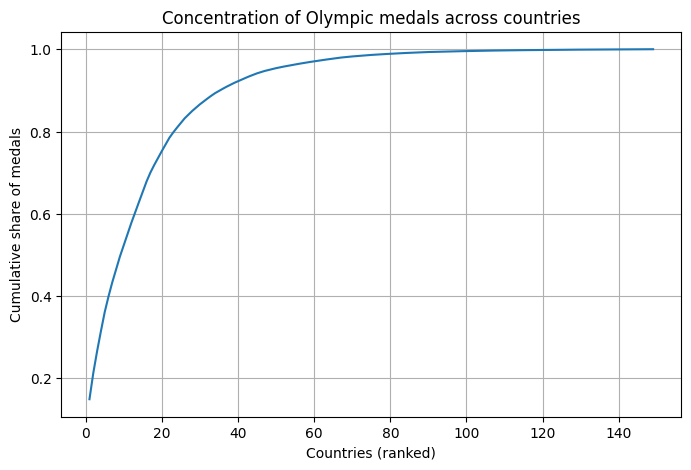

In [18]:
plt.figure(figsize=(8,5))
plt.plot(
    country_total_sorted["Rank"],
    country_total_sorted["Cumulative_Share"]
)

plt.xlabel("Countries (ranked)")
plt.ylabel("Cumulative share of medals")
plt.title("Concentration of Olympic medals across countries")
plt.grid()
plt.show()

## Interpretation

The curve rises very steeply at the beginning, indicating that a small number of countries accumulate a large share of Olympic medals very quickly.

For instance, the first 20–30 countries already account for the vast majority of medals, while the remaining countries contribute only marginally.

This confirms a strong concentration of Olympic success:
most countries win few or no medals, while a limited group dominates consistently.

This pattern reinforces the idea that Olympic performance is highly unequal across countries.

## 5. Stability of Olympic dominance

A second question is whether Olympic power is stable over time.

To explore this, I examine how many distinct countries appear in the annual top 10.

In [23]:
df["Top10_Flag"] = df["Top10_Flag"].astype(str).str.upper() == "VERO"

In [24]:
df["Top10_Flag"].unique()

array([ True, False])

In [25]:
top10_countries = df[df["Top10_Flag"] == True].copy()

unique_top10 = top10_countries["NOC"].nunique()

unique_top10

40

In [26]:
top10_frequency = (
    top10_countries.groupby("NOC")
    .size()
    .reset_index(name="Appearances")
    .sort_values("Appearances", ascending=False)
)

top10_frequency.head(10)

,NOC,Appearances
39,USA,34
23,ITA,31
16,FRA,30
20,GER,26
18,GBR,25
35,SWE,21
22,HUN,20
15,FIN,18
28,NOR,18
24,JPN,16


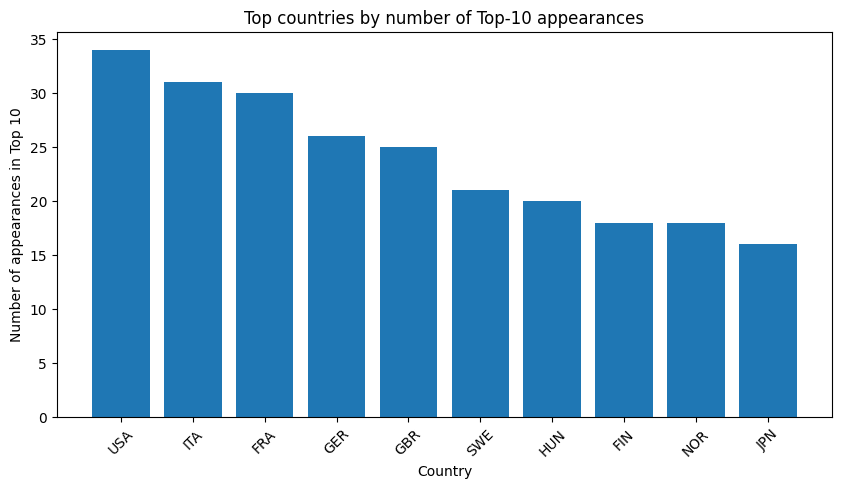

In [27]:
plt.figure(figsize=(10,5))
plt.bar(
    top10_frequency.head(10)["NOC"],
    top10_frequency.head(10)["Appearances"]
)

plt.title("Top countries by number of Top-10 appearances")
plt.xlabel("Country")
plt.ylabel("Number of appearances in Top 10")
plt.xticks(rotation=45)
plt.show()

## Interpretation

The chart shows how frequently countries appear in the Olympic top 10 over time.

Some countries, such as the USA, appear very consistently, indicating a strong and persistent dominance.

However, the presence of several other countries with a high number of appearances suggests that Olympic power is not concentrated in a single country, but rather shared among a relatively stable group.

This indicates that Olympic success is not random:  
it is consistently achieved by a limited set of countries over time.

## 6. Summary statistics

In [28]:
summary_stats = {
    "Number of countries": df["NOC"].nunique(),
    "Total medals in dataset": int(df["Total_Medals"].sum()),
    "Number of distinct top-10 countries": int(unique_top10),
    "Top-10 medal share": float(top10_share)
}

summary_stats

{'Number of countries': 149,
 'Total medals in dataset': 18905,
 'Number of distinct top-10 countries': 40,
 'Top-10 medal share': 0.5236180904522613}

## Conclusion

This exploratory analysis reveals a clear pattern in Olympic performance.

First, Olympic success is highly concentrated:  
the top 10 countries account for more than half of all medals (~52%).

Second, the cumulative distribution shows that medals accumulate very quickly among a small number of countries, while most countries contribute only marginally.

Finally, the analysis of top-10 appearances highlights that Olympic dominance is not random:  
the same countries repeatedly appear among the top performers over time.

Taken together, these results suggest that Olympic success is neither evenly distributed nor purely merit-based.  
Instead, it appears to be driven by persistent structural advantages concentrated in a limited group of countries.

This raises a key question:  
what factors explain this persistent dominance?

In the next step, I explore whether economic power can help explain these patterns.